# French medical NER — training, evaluation and comparison

This notebook runs the complete NER experiment while keeping the neural architectures in the separate `ner_models.py` module.

The experiment now studies **two factors at the same time**:

1. which NER dataset configuration is used;
2. how much labelled TRAIN data is available.

The protocol is:

- three dataset configurations: **MEDLINE**, **EMEA**, and **MEDLINE + EMEA**;
- two architectures: **BiLSTM** and **CNN**;
- three embedding conditions: **random**, **frozen pretrained**, and **fine-tuned pretrained**;
- three labelled-data regimes: **100%**, **75%**, and **50%** of TRAIN;
- when enabled, DEV is reduced by the same fraction because it is used only for early stopping;
- TEST is **never reduced**;
- vocabulary, label mapping and initial embedding matrices are built once from the original full TRAIN split and are kept fixed across data fractions;
- model selection is performed only with **DEV seqeval entity F1**;
- TEST is evaluated only after the best DEV checkpoint has been restored;
- final evaluation reports **entity F1** and **sentence exact match**.

Keeping the vocabulary and embedding matrices fixed is intentional: it isolates the effect of having fewer labelled training sentences instead of mixing data scarcity with a changing vocabulary/OOV rate.


## 1. Imports and experiment configuration


In [14]:
# Uncomment if needed:
# %pip install torch numpy pandas matplotlib gensim seqeval

In [15]:
import copy
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from gensim.models import FastText, Word2Vec
from seqeval.metrics import f1_score
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

from ner_models import build_model

In [16]:
DATASET_CONFIGS = {
     "EMEA": ["EMEA"],
    "MEDLINE": ["MEDLINE"],
    "MEDLINE + EMEA": ["MEDLINE", "EMEA"],
}

ARCHITECTURES = ["LSTM", "CNN"]

# 1.00 = original experiment
# 0.85 = 15% reduction in TRAIN
# 0.70 = 30% reduction in TRAIN

TRAIN_FRACTIONS = [1.00, 0.85 ,0.70]

# If True, DEV uses the same fraction as TRAIN.
# TEST always stays at 100%.
REDUCE_DEV_WITH_TRAIN = True

CONLL_DIR = Path("TP_ISD2020/QUAERO_FrenchMed")
MODEL_DIR = Path("models")
SELECTION_FILE = MODEL_DIR / "embedding_selection.json"

SEED = 42
BATCH_SIZE = 32
HIDDEN_DIM = 128
LSTM_LAYERS = 2
NUM_FILTERS = 128
CNN_KERNEL_SIZE = 3
DROPOUT = 0.3
EPOCHS = 200
PATIENCE = 5

MODEL_LR = 1e-3
PRETRAINED_LR = 5e-4
WEIGHT_DECAY = 1e-4

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
PAD_LABEL_ID = -100

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()
print(f"Device: {DEVICE}")
print(f"Dataset configurations: {list(DATASET_CONFIGS)}")
print(f"TRAIN fractions: {TRAIN_FRACTIONS}")
print(f"Reduce DEV with TRAIN: {REDUCE_DEV_WITH_TRAIN}")


Device: mps
Dataset configurations: ['EMEA', 'MEDLINE', 'MEDLINE + EMEA']
TRAIN fractions: [1.0, 0.85, 0.7]
Reduce DEV with TRAIN: True


## 2. Load and prepare the three dataset configurations

MEDLINE and EMEA keep their official TRAIN, DEV and TEST splits. The combined configuration concatenates the corresponding split from both corpora.

For every configuration independently:

- the vocabulary is built from the **original full TRAIN split**;
- tokens are lowercased for vocabulary and embedding lookup;
- `<UNK>` represents DEV/TEST words unseen in the original TRAIN split;
- the BIO label mapping is built from the original TRAIN split;
- padding is introduced only when batches are created.

The reduced-data experiment changes only which labelled TRAIN/DEV sentences are used. This keeps the vocabulary and embedding initialization identical across 100%, 85% and 70%, so the comparison isolates the amount of supervised data.


In [17]:
def conll_to_sentences(text):
    sentences = []
    tokens, labels = [], []

    for line in text.splitlines():
        if not line.strip():
            if tokens:
                sentences.append({"tokens": tokens, "labels": labels})
                tokens, labels = [], []
            continue

        columns = line.split()
        tokens.append(columns[1])
        labels.append(columns[-1])

    if tokens:
        sentences.append({"tokens": tokens, "labels": labels})

    return sentences


def load_split(dataset_names, split):
    samples = []

    for dataset in dataset_names:
        path = CONLL_DIR / dataset / f"{dataset}{split}_layer1_ID.conll"
        samples.extend(conll_to_sentences(path.read_text(encoding="utf-8")))

    return samples


def encode_dataset(samples, word2idx, label2idx):
    encoded = []

    for sample in samples:
        token_ids = [
            word2idx.get(token.lower(), word2idx[UNK_TOKEN])
            for token in sample["tokens"]
        ]
        label_ids = [label2idx[label] for label in sample["labels"]]

        encoded.append((
            torch.tensor(token_ids, dtype=torch.long),
            torch.tensor(label_ids, dtype=torch.long),
        ))

    return encoded

def remove_no_entity_sentences(samples):
    """Keep only sentences containing at least one named entity."""
    return [
        sample
        for sample in samples
        if any(label != "O" for label in sample["labels"])
    ]


def prepare_dataset(dataset_names):
    datasets = {
        split: load_split(dataset_names, split)
        for split in ("train", "dev", "test")
    }

    # Remove sentences where every token is tagged as "O"
    datasets = {
        split: remove_no_entity_sentences(samples)
        for split, samples in datasets.items()
    }

    train_words = sorted({
        token.lower()
        for sample in datasets["train"]
        for token in sample["tokens"]
    })

    word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    word2idx.update({
        word: index
        for index, word in enumerate(train_words, start=2)
    })

    labels = sorted({
        label
        for sample in datasets["train"]
        for label in sample["labels"]
    })

    label2idx = {
        label: index
        for index, label in enumerate(labels)
    }

    idx2label = {
        index: label
        for label, index in label2idx.items()
    }

    encoded = {
        split: encode_dataset(samples, word2idx, label2idx)
        for split, samples in datasets.items()
    }

    return {
        "datasets": datasets,
        "train_words": train_words,
        "word2idx": word2idx,
        "label2idx": label2idx,
        "idx2label": idx2label,
        "encoded": encoded,
    }


dataset_contexts = {
    name: prepare_dataset(dataset_names)
    for name, dataset_names in DATASET_CONFIGS.items()
}


def fraction_size(n_samples, fraction):
    """Number of samples kept for a given fraction."""
    return max(1, int(round(n_samples * fraction)))


def subset_for_fraction(context, split, fraction):
    """
    Return a deterministic nested subset.

    For a given split, the 25% subset is contained in the 50% subset.
    TEST is not passed through this function.
    """
    data = context["encoded"][split]

    if fraction == 1.0:
        return data

    split_seed = SEED + {"train": 0, "dev": 1}[split]
    generator = torch.Generator().manual_seed(split_seed)
    permutation = torch.randperm(len(data), generator=generator).tolist()

    n_keep = fraction_size(len(data), fraction)
    selected_indices = permutation[:n_keep]

    return [data[index] for index in selected_indices]


def dev_fraction_for(train_fraction):
    return train_fraction if REDUCE_DEV_WITH_TRAIN else 1.0


In [18]:
dataset_rows = []
budget_rows = []

for dataset_name, context in dataset_contexts.items():
    print(f"\n{dataset_name}")

    for split, samples in context["datasets"].items():
        n_tokens = sum(len(sample["tokens"]) for sample in samples)

        print(
            f"{split:>5}: {len(samples):>5} sentences | "
            f"{n_tokens:>7} tokens"
        )

        dataset_rows.append({
            "dataset": dataset_name,
            "split": split,
            "sentences": len(samples),
            "tokens": n_tokens,
            "vocabulary": len(context["word2idx"]),
            "BIO labels": len(context["label2idx"]),
        })

    for train_fraction in TRAIN_FRACTIONS:
        dev_fraction = dev_fraction_for(train_fraction)

        budget_rows.append({
            "dataset": dataset_name,
            "train_fraction": train_fraction,
            "train_reduction": 1 - train_fraction,
            "train_sentences": fraction_size(
                len(context["encoded"]["train"]),
                train_fraction,
            ),
            "dev_fraction": dev_fraction,
            "dev_sentences": fraction_size(
                len(context["encoded"]["dev"]),
                dev_fraction,
            ),
            "test_sentences": len(context["encoded"]["test"]),
        })


dataset_summary = pd.DataFrame(dataset_rows)
data_budget_summary = pd.DataFrame(budget_rows)

display(dataset_summary)
display(
    data_budget_summary
    .sort_values(["dataset", "train_fraction"], ascending=[True, False])
    .reset_index(drop=True)
)



EMEA
train:   636 sentences |   14641 tokens
  dev:   550 sentences |   12067 tokens
 test:   515 sentences |   11833 tokens

MEDLINE
train:   791 sentences |   11097 tokens
  dev:   792 sentences |   11079 tokens
 test:   804 sentences |   11636 tokens

MEDLINE + EMEA
train:  1427 sentences |   25738 tokens
  dev:  1342 sentences |   23146 tokens
 test:  1319 sentences |   23469 tokens


,dataset,split,sentences,tokens,vocabulary,BIO labels
0,EMEA,train,636,14641,2295,21
1,EMEA,dev,550,12067,2295,21
2,EMEA,test,515,11833,2295,21
3,MEDLINE,train,791,11097,3362,21
4,MEDLINE,dev,792,11079,3362,21
5,MEDLINE,test,804,11636,3362,21
6,MEDLINE + EMEA,train,1427,25738,4970,21
7,MEDLINE + EMEA,dev,1342,23146,4970,21
8,MEDLINE + EMEA,test,1319,23469,4970,21


,dataset,train_fraction,train_reduction,train_sentences,dev_fraction,dev_sentences,test_sentences
0,EMEA,1.00,0.00,636,1.00,550,515
1,EMEA,0.85,0.15,541,0.85,468,515
2,EMEA,0.70,0.30,445,0.70,385,515
3,MEDLINE,1.00,0.00,791,1.00,792,804
4,MEDLINE,0.85,0.15,672,0.85,673,804
5,MEDLINE,0.70,0.30,554,0.70,554,804
6,MEDLINE + EMEA,1.00,0.00,1427,1.00,1342,1319
7,MEDLINE + EMEA,0.85,0.15,1213,0.85,1141,1319
8,MEDLINE + EMEA,0.70,0.30,999,0.70,939,1319


## 3. Batches and deterministic data reduction

Padding is performed independently inside each batch. Labels added by padding use `PAD_LABEL_ID = -100`, so they are ignored by the loss and by the final metrics.

For TRAIN and DEV, `make_loader(...)` can receive a fraction. The subsets are deterministic and nested. This is preferable to drawing a new random sample for every condition because the comparison then changes only by **adding more labelled examples**.


In [19]:
def collate_batch(batch, pad_token_id):
    tokens, labels = zip(*batch)

    tokens = pad_sequence(
        tokens,
        batch_first=True,
        padding_value=pad_token_id,
    )
    labels = pad_sequence(
        labels,
        batch_first=True,
        padding_value=PAD_LABEL_ID,
    )

    return tokens, labels


def make_loader(
    context,
    split,
    shuffle=False,
    fraction=1.0,
):
    if split == "test":
        data = context["encoded"]["test"]
    else:
        data = subset_for_fraction(
            context,
            split,
            fraction,
        )

    generator = (
        torch.Generator().manual_seed(SEED)
        if shuffle
        else None
    )

    return DataLoader(
        data,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        collate_fn=lambda batch: collate_batch(
            batch,
            context["word2idx"][PAD_TOKEN],
        ),
        generator=generator,
    )


## 4. Load the pretrained embeddings

The Gensim models are loaded once. Each NER dataset configuration will later construct its own embedding matrix because its TRAIN vocabulary is different.

In [20]:
selection = json.loads(SELECTION_FILE.read_text(encoding="utf-8"))
embedding_files = selection["embeddings"]

pretrained_vectors = {}

for corpus, files in embedding_files.items():
    pretrained_vectors[corpus] = {}

    for name, filename in files.items():
        model_class = FastText if "fasttext" in name.lower() else Word2Vec
        model = model_class.load(str(MODEL_DIR / filename))
        pretrained_vectors[corpus][name] = model.wv

        print(
            f"{corpus:>5} | {name:<10} | "
            f"{len(model.wv):>6} vectors | "
            f"dim={model.wv.vector_size}"
        )


EMBEDDING_DIM = next(
    iter(next(iter(pretrained_vectors.values())).values())
).vector_size

  MED | cbow       |   8088 vectors | dim=100
  MED | skipgram   |   8088 vectors | dim=100
  MED | fasttext   |   8088 vectors | dim=100
PRESS | cbow       |  38279 vectors | dim=100
PRESS | skipgram   |  38279 vectors | dim=100
PRESS | fasttext   |  38279 vectors | dim=100


## 5. Embedding vocabulary coverage

Coverage is computed separately for MEDLINE, EMEA and MEDLINE + EMEA using only each configuration's TRAIN vocabulary.

In [21]:
OSPL_FILES = {
    "MED": Path("TP_ISD2020/QUAERO_FrenchMed/QUAERO_FrenchMed_traindev.ospl"),
    "PRESS": Path("TP_ISD2020/QUAERO_FrenchPress/QUAERO_FrenchPress_traindev.ospl"),
}


def load_ospl_vocabulary(path):
    return {
        token.lower()
        for line in path.read_text(encoding="utf-8").splitlines()
        for token in line.split()
    }


ospl_vocabularies = {
    corpus: load_ospl_vocabulary(path)
    for corpus, path in OSPL_FILES.items()
}

coverage_rows = []

for dataset_name, context in dataset_contexts.items():
    conll_vocabulary = set(context["train_words"])

    for corpus, ospl_vocabulary in ospl_vocabularies.items():
        covered = conll_vocabulary & ospl_vocabulary
        missing = conll_vocabulary - ospl_vocabulary

        coverage_rows.append({
            "dataset": dataset_name,
            "corpus": corpus,
            "OSPL vocabulary": len(ospl_vocabulary),
            "CoNLL vocabulary": len(conll_vocabulary),
            "covered": len(covered),
            "missing": len(missing),
            "coverage (%)": 100 * len(covered) / len(conll_vocabulary),
        })


coverage = pd.DataFrame(coverage_rows)
display(
    coverage.sort_values(["dataset", "corpus"])
    .reset_index(drop=True)
    .round(2)
)

,dataset,corpus,OSPL vocabulary,CoNLL vocabulary,covered,missing,coverage (%)
0,EMEA,MED,8088,2293,2293,0,100.00
1,EMEA,PRESS,38279,2293,1599,694,69.73
2,MEDLINE,MED,8088,3360,3360,0,100.00
3,MEDLINE,PRESS,38279,3360,1625,1735,48.36
4,MEDLINE + EMEA,MED,8088,4968,4968,0,100.00
5,MEDLINE + EMEA,PRESS,38279,4968,2652,2316,53.38


## 6. Build comparable embedding matrices

The random matrix is created once per dataset configuration. Every pretrained matrix starts from that same random matrix and replaces rows only when a pretrained vector exists.

Therefore:

- **random** starts from the common random initialization and is trainable;
- **frozen** starts from the pretrained matrix and is fixed;
- **fine-tuned** starts from exactly the same pretrained matrix but is trainable;
- missing pretrained words retain the same random initialization;
- `<PAD>` is always zero.

In [22]:
def build_random_matrix(context):
    generator = torch.Generator().manual_seed(SEED)

    matrix = torch.randn(
        len(context["word2idx"]),
        EMBEDDING_DIM,
        generator=generator,
    ) * 0.1

    matrix[context["word2idx"][PAD_TOKEN]] = 0
    return matrix


def build_pretrained_matrix(vectors, context, random_matrix):
    matrix = random_matrix.clone()

    for word, index in context["word2idx"].items():
        if word == PAD_TOKEN:
            continue

        if word in vectors:
            matrix[index] = torch.tensor(
                np.asarray(vectors[word]),
                dtype=torch.float32,
            )

    matrix[context["word2idx"][PAD_TOKEN]] = 0
    return matrix


def build_embedding_matrices(context):
    random_matrix = build_random_matrix(context)

    pretrained_matrices = {
        corpus: {
            name: build_pretrained_matrix(
                vectors,
                context,
                random_matrix,
            )
            for name, vectors in group.items()
        }
        for corpus, group in pretrained_vectors.items()
    }

    return random_matrix, pretrained_matrices

## 7. Models from `ner_models.py`

The model definitions are intentionally outside the notebook.

- **BiLSTM:** two bidirectional LSTM layers followed by dropout and token classification.
- **CNN:** a 1D convolution over neighbouring token embeddings followed by dropout and token classification.

Only the embedding behaviour changes between random, frozen and fine-tuned conditions.

In [23]:
def create_model(architecture, embedding_matrix, mode, context):
    return build_model(
        architecture=architecture,
        embedding_matrix=embedding_matrix,
        mode=mode,
        padding_idx=context["word2idx"][PAD_TOKEN],
        num_labels=len(context["label2idx"]),
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
        num_layers=LSTM_LAYERS,
        num_filters=NUM_FILTERS,
        kernel_size=CNN_KERNEL_SIZE,
    )

## 8. Training and evaluation

The checkpoint protocol is unchanged inside every data regime:

1. choose a TRAIN fraction: **100%**, **85%**, **70%**;
2. train only on that TRAIN subset;
3. evaluate after every epoch on DEV;
4. if `REDUCE_DEV_WITH_TRAIN = True`, DEV uses the same fraction as TRAIN;
5. keep the checkpoint with the highest **DEV seqeval entity F1**;
6. stop after `PATIENCE` epochs without improvement;
7. restore the best DEV checkpoint;
8. evaluate that checkpoint on the **full TEST set**.

`dev_loss` is recorded only to visualize optimization. It is **not** used for early stopping or model selection.


In [24]:
criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_LABEL_ID,
    reduction="sum",
)


def optimizer_for(model, mode):
    model_params = [
        parameter
        for name, parameter in model.named_parameters()
        if not name.startswith("embedding.")
    ]

    groups = [{
        "params": model_params,
        "lr": MODEL_LR,
    }]

    if mode == "random":
        groups.append({
            "params": model.embedding.parameters(),
            "lr": MODEL_LR,
        })
    elif mode == "fine_tuned":
        groups.append({
            "params": model.embedding.parameters(),
            "lr": PRETRAINED_LR,
        })

    return torch.optim.Adam(
        groups,
        weight_decay=WEIGHT_DECAY,
    )


def loss_on_loader(model, loader, training=False, optimizer=None):
    model.train() if training else model.eval()

    total_loss = 0.0
    total_tokens = 0

    context_manager = torch.enable_grad() if training else torch.no_grad()

    with context_manager:
        for tokens, labels in loader:
            tokens = tokens.to(DEVICE)
            labels = labels.to(DEVICE)

            if training:
                optimizer.zero_grad()

            logits = model(tokens)
            loss_sum = criterion(
                logits.reshape(-1, logits.size(-1)),
                labels.reshape(-1),
            )

            n_tokens = (labels != PAD_LABEL_ID).sum()
            loss = loss_sum / n_tokens

            if training:
                loss.backward()
                optimizer.step()

            total_loss += loss_sum.item()
            total_tokens += n_tokens.item()

    return total_loss / total_tokens


@torch.no_grad()
def evaluate(model, loader, idx2label):
    model.eval()

    gold_sequences = []
    predicted_sequences = []

    for tokens, labels in loader:
        tokens = tokens.to(DEVICE)
        labels = labels.to(DEVICE)

        predictions = model(tokens).argmax(dim=-1)

        for gold_row, predicted_row in zip(labels, predictions):
            valid = gold_row != PAD_LABEL_ID

            gold_sequences.append([
                idx2label[index]
                for index in gold_row[valid].cpu().tolist()
            ])
            predicted_sequences.append([
                idx2label[index]
                for index in predicted_row[valid].cpu().tolist()
            ])

    return {
        "entity_f1": f1_score(
            gold_sequences,
            predicted_sequences,
        ),
        "sentence_exact_match": np.mean([
            gold == predicted
            for gold, predicted in zip(
                gold_sequences,
                predicted_sequences,
            )
        ]),
    }

In [25]:
def train_model(
    context,
    architecture,
    embedding_matrix,
    mode,
    train_fraction,
    run_label,
):
    set_seed()

    model = create_model(
        architecture=architecture,
        embedding_matrix=embedding_matrix,
        mode=mode,
        context=context,
    ).to(DEVICE)

    optimizer = optimizer_for(model, mode)

    dev_fraction = dev_fraction_for(train_fraction)

    train_loader = make_loader(
        context,
        "train",
        shuffle=True,
        fraction=train_fraction,
    )
    dev_loader = make_loader(
        context,
        "dev",
        fraction=dev_fraction,
    )

    history = []
    best_f1 = -1.0
    best_epoch = 0
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(1, EPOCHS + 1):
        train_loss = loss_on_loader(
            model,
            train_loader,
            training=True,
            optimizer=optimizer,
        )
        dev_loss = loss_on_loader(
            model,
            dev_loader,
            training=False,
        )
        dev_metrics = evaluate(
            model,
            dev_loader,
            context["idx2label"],
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "dev_loss": dev_loss,
            "dev_entity_f1": dev_metrics["entity_f1"],
            "dev_sentence_exact_match": dev_metrics["sentence_exact_match"],
        })

        if dev_metrics["entity_f1"] > best_f1:
            best_f1 = dev_metrics["entity_f1"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch % 2 == 0 or epoch == 1:
            print(
                f"{run_label} | epoch {epoch:03d} | "
                f"train loss {train_loss:.4f} | "
                f"dev loss {dev_loss:.4f} | "
                f"dev entity F1 {dev_metrics['entity_f1']:.4f} | "
                f"sentence exact {dev_metrics['sentence_exact_match']:.4f}"
            )

        if epochs_without_improvement >= PATIENCE:
            print(
                f"{run_label} | early stopping after {epoch} epochs "
                f"(best epoch {best_epoch}, best dev entity F1 {best_f1:.4f})"
            )
            break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), best_epoch


## 9. Run every experiment

For each dataset configuration, architecture and labelled-data regime, the notebook trains:

- one random baseline;
- every pretrained embedding in frozen mode;
- the same pretrained embedding in fine-tuned mode.

The three TRAIN regimes are:

- **100%**: original experiment;
- **85%**: 15% reduction.
- **70%**: 30% reduction;

TEST remains untouched. The `runs` dictionary stores each training history together with the selected checkpoint epoch and its DEV/TEST scores.


In [26]:
runs = {}
dev_rows = []
test_rows = []

for dataset_name, context in dataset_contexts.items():
    print("\n" + "=" * 80)
    print(f"DATASET: {dataset_name}")
    print("=" * 80)

    # Built once and reused for all data fractions.
    random_matrix, pretrained_matrices = build_embedding_matrices(context)

    for train_fraction in TRAIN_FRACTIONS:
        dev_fraction = dev_fraction_for(train_fraction)

        print(
            f"\nDATA REGIME: {train_fraction:.0%} TRAIN | "
            f"{dev_fraction:.0%} DEV | 100% TEST"
        )

        for architecture in ARCHITECTURES:
            experiments = [(
                "RANDOM",
                "random",
                "random",
                random_matrix,
            )]

            for corpus, group in pretrained_matrices.items():
                for embedding_name, matrix in group.items():
                    experiments.extend([
                        (corpus, embedding_name, "frozen", matrix),
                        (corpus, embedding_name, "fine_tuned", matrix),
                    ])

            for corpus, embedding_name, mode, matrix in experiments:
                run_label = (
                    f"{dataset_name} | {architecture} | "
                    f"TRAIN {train_fraction:.0%} | "
                    f"{corpus} | {embedding_name} | {mode.upper()}"
                )

                print(f"\n{run_label}")

                model, history, best_epoch = train_model(
                    context=context,
                    architecture=architecture,
                    embedding_matrix=matrix,
                    mode=mode,
                    train_fraction=train_fraction,
                    run_label=run_label,
                )

                dev_metrics = evaluate(
                    model,
                    make_loader(
                        context,
                        "dev",
                        fraction=dev_fraction,
                    ),
                    context["idx2label"],
                )
                test_metrics = evaluate(
                    model,
                    make_loader(context, "test"),
                    context["idx2label"],
                )

                key = (
                    dataset_name,
                    train_fraction,
                    architecture,
                    corpus,
                    embedding_name,
                    mode,
                )

                runs[key] = {
                    "history": history,
                    "best_epoch": best_epoch,
                    "dev_metrics": dev_metrics,
                    "test_metrics": test_metrics,
                }

                common = {
                    "dataset": dataset_name,
                    "train_fraction": train_fraction,
                    "train_reduction": 1 - train_fraction,
                    "dev_fraction": dev_fraction,
                    "train_sentences": fraction_size(
                        len(context["encoded"]["train"]),
                        train_fraction,
                    ),
                    "dev_sentences": fraction_size(
                        len(context["encoded"]["dev"]),
                        dev_fraction,
                    ),
                    "architecture": architecture,
                    "corpus": corpus,
                    "embedding": embedding_name,
                    "mode": mode,
                    "best_epoch": best_epoch,
                }

                dev_rows.append({**common, **dev_metrics})
                test_rows.append({**common, **test_metrics})

                model.cpu()
                del model


dev_results = pd.DataFrame(dev_rows)
test_results = pd.DataFrame(test_rows)



DATASET: EMEA

DATA REGIME: 100% TRAIN | 100% DEV | 100% TEST

EMEA | LSTM | TRAIN 100% | RANDOM | random | RANDOM
EMEA | LSTM | TRAIN 100% | RANDOM | random | RANDOM | epoch 001 | train loss 1.8845 | dev loss 1.1018 | dev entity F1 0.0000 | sentence exact 0.0000
EMEA | LSTM | TRAIN 100% | RANDOM | random | RANDOM | epoch 002 | train loss 1.0719 | dev loss 1.0584 | dev entity F1 0.0000 | sentence exact 0.0000
EMEA | LSTM | TRAIN 100% | RANDOM | random | RANDOM | epoch 004 | train loss 1.0384 | dev loss 1.0391 | dev entity F1 0.0000 | sentence exact 0.0000
EMEA | LSTM | TRAIN 100% | RANDOM | random | RANDOM | epoch 006 | train loss 0.9046 | dev loss 0.8957 | dev entity F1 0.0000 | sentence exact 0.0000
EMEA | LSTM | TRAIN 100% | RANDOM | random | RANDOM | early stopping after 6 epochs (best epoch 1, best dev entity F1 0.0000)

EMEA | LSTM | TRAIN 100% | MED | cbow | FROZEN
EMEA | LSTM | TRAIN 100% | MED | cbow | FROZEN | epoch 001 | train loss 1.6513 | dev loss 1.0658 | dev entity F1 0

In [27]:
from pathlib import Path
import pickle

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Save tabular results
dev_results.to_csv(
    RESULTS_DIR / "dev_results.csv",
    index=False
)

test_results.to_csv(
    RESULTS_DIR / "test_results.csv",
    index=False
)

# Save complete run information (histories, metrics, best epochs, etc.)
with open(RESULTS_DIR / "runs.pkl", "wb") as f:
    pickle.dump(runs, f)

print(f"Results saved in: {RESULTS_DIR.resolve()}")

Results saved in: /Users/fserracrespi/Desktop/Paris Saclay/NLP Today/Workshop_1_NLP_Today/Workshop3/results


## 10. DEV results

These scores describe the checkpoint chosen by DEV entity F1 for every experiment and data regime.

Remember that, when `REDUCE_DEV_WITH_TRAIN = True`, the DEV set itself is also smaller in the 50% and 25% regimes.


In [28]:
display(
    dev_results.sort_values(
        ["dataset", "train_fraction", "architecture", "entity_f1"],
        ascending=[True, False, True, False],
    )
    .reset_index(drop=True)
    .round(4)
)


,dataset,train_fraction,train_reduction,dev_fraction,train_sentences,dev_sentences,architecture,corpus,embedding,mode,best_epoch,entity_f1,sentence_exact_match
0,EMEA,1.0,0.0,1.0,636,550,CNN,RANDOM,random,random,24,0.4676,0.0964
1,EMEA,1.0,0.0,1.0,636,550,CNN,PRESS,cbow,fine_tuned,18,0.4457,0.1436
2,EMEA,1.0,0.0,1.0,636,550,CNN,PRESS,cbow,frozen,20,0.4315,0.1236
3,EMEA,1.0,0.0,1.0,636,550,CNN,MED,skipgram,fine_tuned,34,0.4275,0.0891
4,EMEA,1.0,0.0,1.0,636,550,CNN,MED,cbow,fine_tuned,46,0.4212,0.0855
...,...,...,...,...,...,...,...,...,...,...,...,...,...
229,MEDLINE + EMEA,0.7,0.3,0.7,999,939,LSTM,MED,skipgram,frozen,14,0.3429,0.0650
230,MEDLINE + EMEA,0.7,0.3,0.7,999,939,LSTM,PRESS,skipgram,fine_tuned,14,0.3393,0.0863
231,MEDLINE + EMEA,0.7,0.3,0.7,999,939,LSTM,PRESS,skipgram,frozen,14,0.3358,0.0799
232,MEDLINE + EMEA,0.7,0.3,0.7,999,939,LSTM,PRESS,fasttext,frozen,15,0.3144,0.0479


## 11. Loss curves

To keep the automatic output readable, the notebook plots the **DEV-selected best run for each dataset × TRAIN fraction × architecture**.

This selection uses DEV entity F1, never TEST.

The helper `plot_run_loss(...)` can also be used to inspect the loss curve of any individual experiment.


In [29]:
def plot_loss_history(history, title):
    ax = history.plot(
        x="epoch",
        y=["train_loss", "dev_loss"],
        figsize=(9, 4),
    )
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.set_title(title)
    ax.legend(["Train loss", "DEV loss"])
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_run_loss(
    dataset,
    train_fraction,
    architecture,
    corpus,
    embedding,
    mode,
):
    key = (
        dataset,
        train_fraction,
        architecture,
        corpus,
        embedding,
        mode,
    )
    history = runs[key]["history"]

    plot_loss_history(
        history,
        (
            f"{dataset} | TRAIN {train_fraction:.0%} | "
            f"{architecture} | {corpus} | {embedding} | {mode}"
        ),
    )


,dataset,train_fraction,train_reduction,dev_fraction,train_sentences,dev_sentences,architecture,corpus,embedding,mode,best_epoch,entity_f1,sentence_exact_match
0,EMEA,1.00,0.00,1.00,636,550,CNN,RANDOM,random,random,24,0.4676,0.0964
1,EMEA,1.00,0.00,1.00,636,550,LSTM,PRESS,cbow,fine_tuned,21,0.5093,0.1618
2,EMEA,0.85,0.15,0.85,541,468,CNN,RANDOM,random,random,27,0.4750,0.0940
3,EMEA,0.85,0.15,0.85,541,468,LSTM,PRESS,cbow,frozen,27,0.4930,0.1603
4,EMEA,0.70,0.30,0.70,445,385,CNN,RANDOM,random,random,32,0.4705,0.0753
5,EMEA,0.70,0.30,0.70,445,385,LSTM,PRESS,cbow,frozen,15,0.4823,0.1091
6,MEDLINE,1.00,0.00,1.00,791,792,CNN,PRESS,cbow,fine_tuned,49,0.3331,0.0568
7,MEDLINE,1.00,0.00,1.00,791,792,LSTM,MED,fasttext,fine_tuned,18,0.3358,0.0720
8,MEDLINE,0.85,0.15,0.85,672,673,CNN,RANDOM,random,random,30,0.3069,0.0505
9,MEDLINE,0.85,0.15,0.85,672,673,LSTM,MED,fasttext,fine_tuned,18,0.3069,0.0698


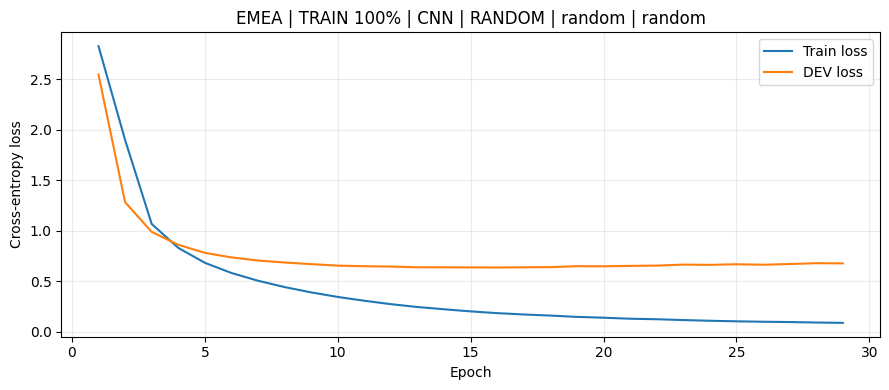

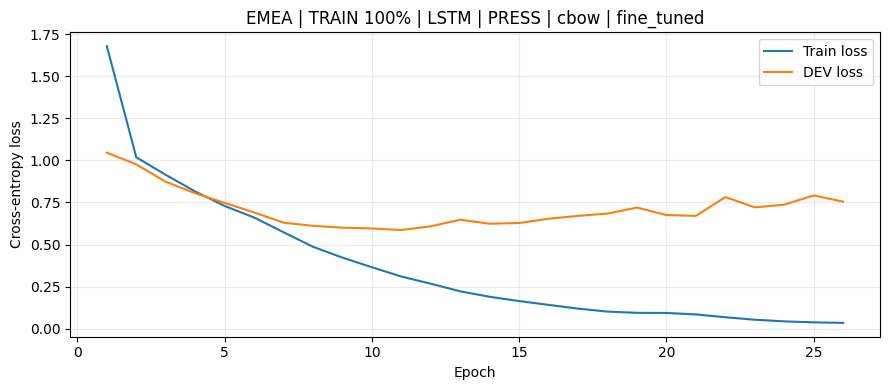

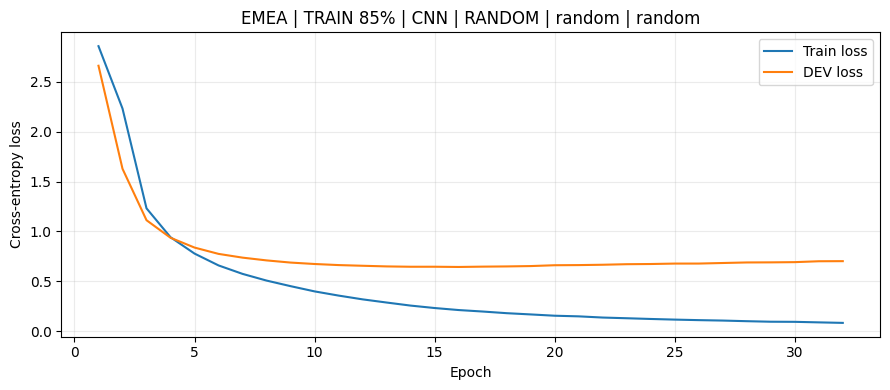

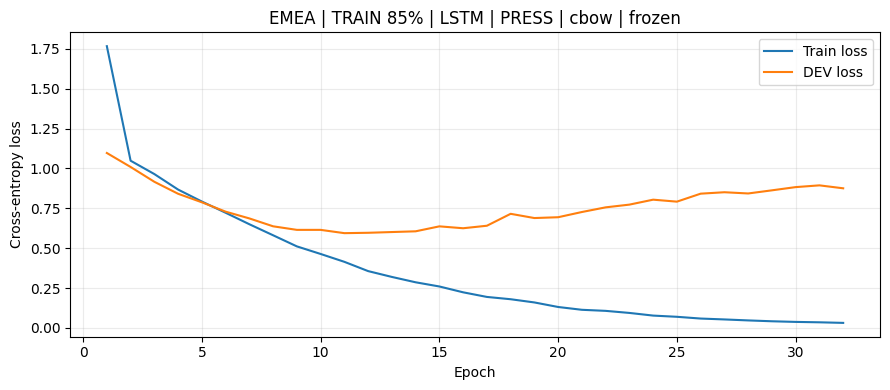

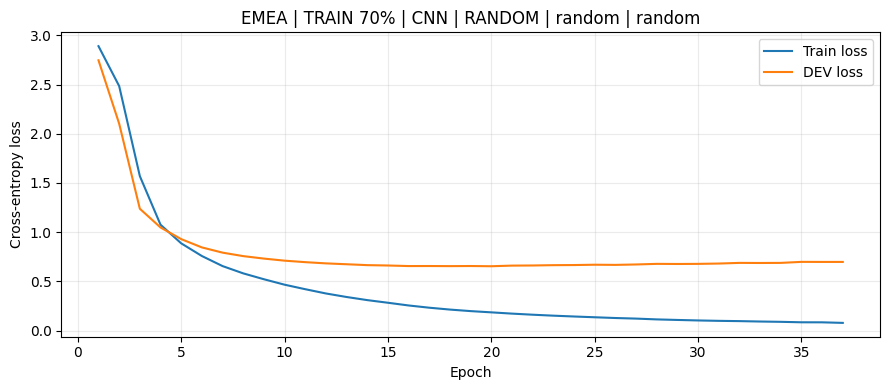

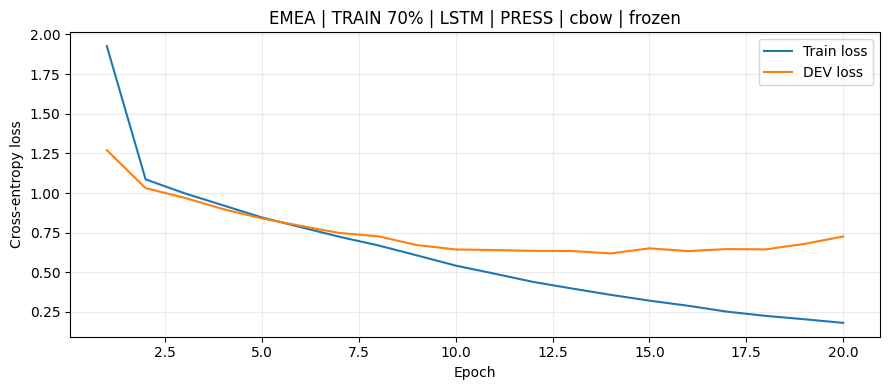

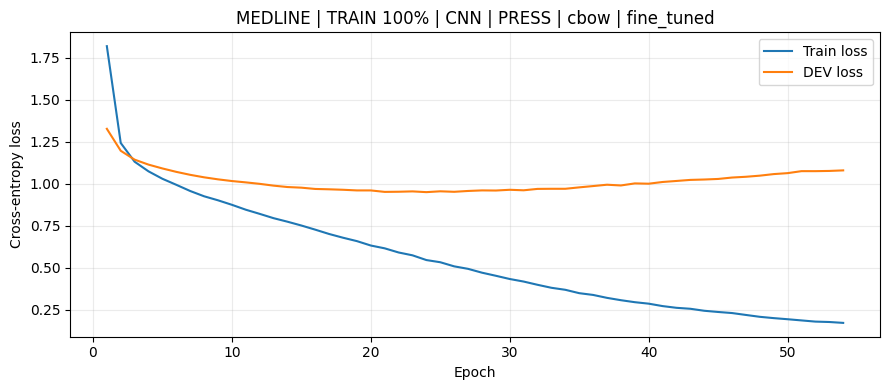

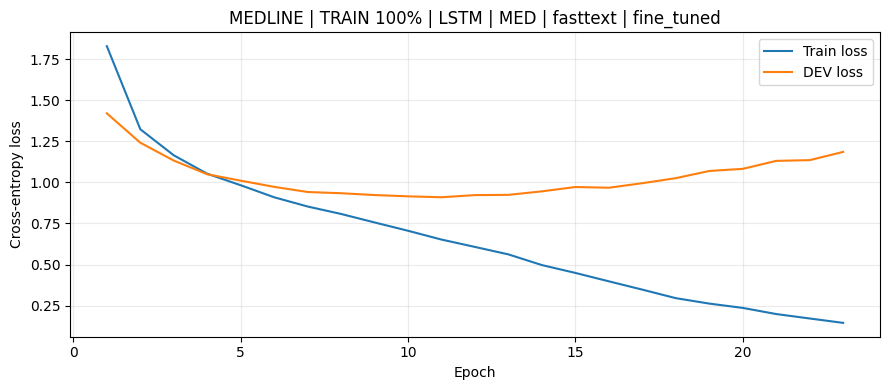

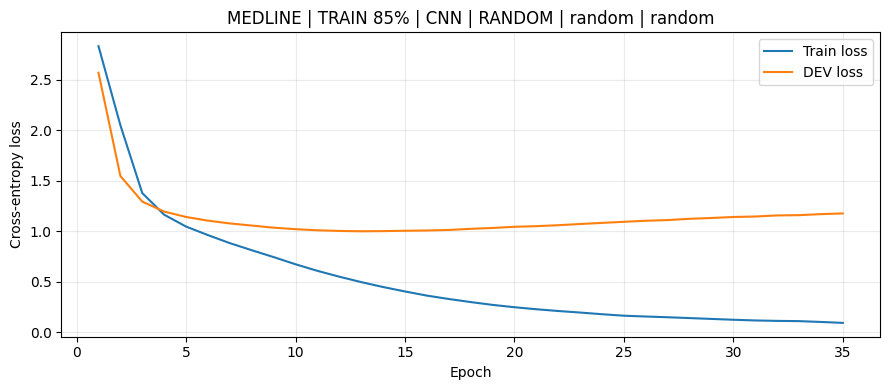

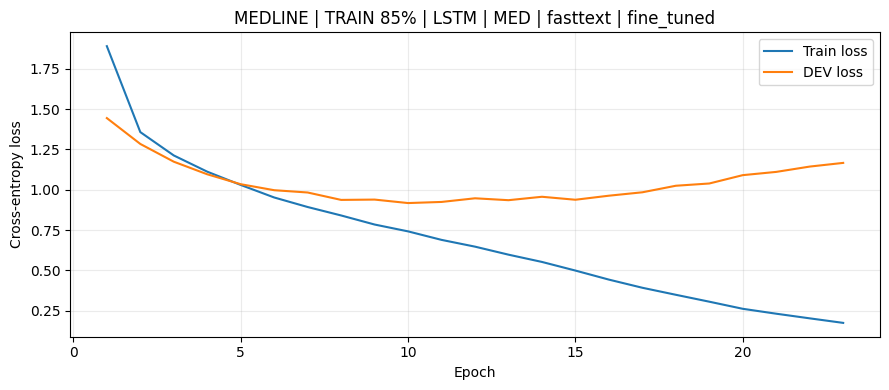

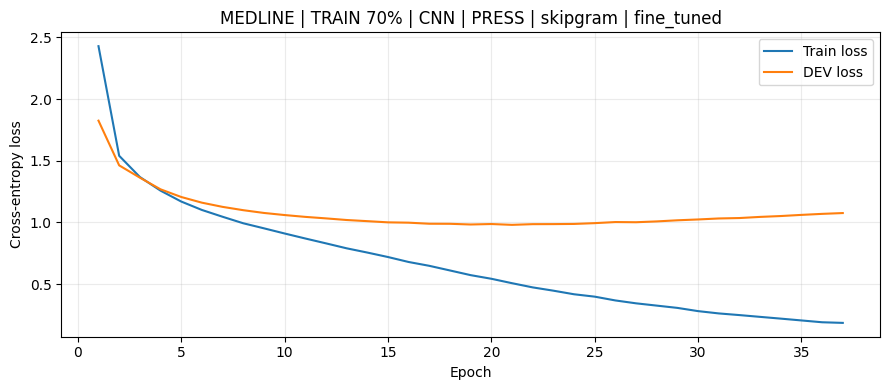

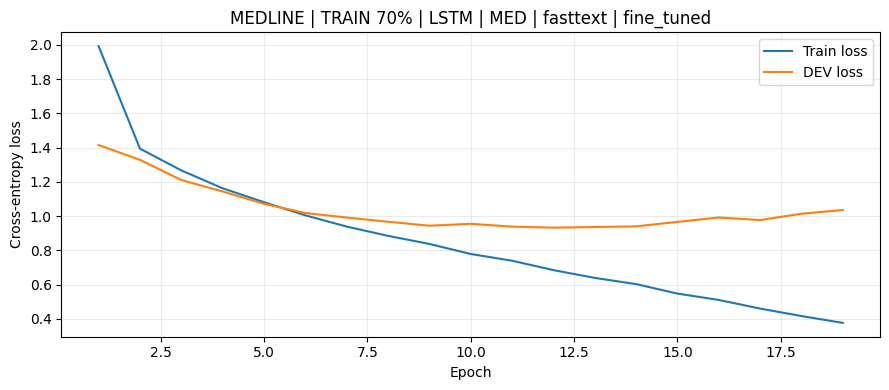

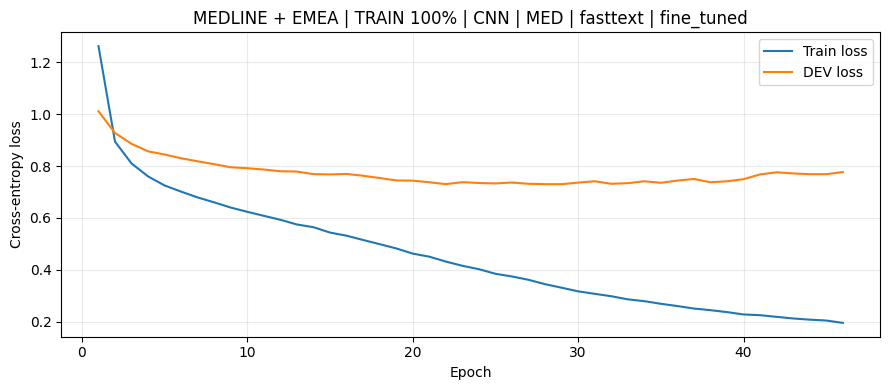

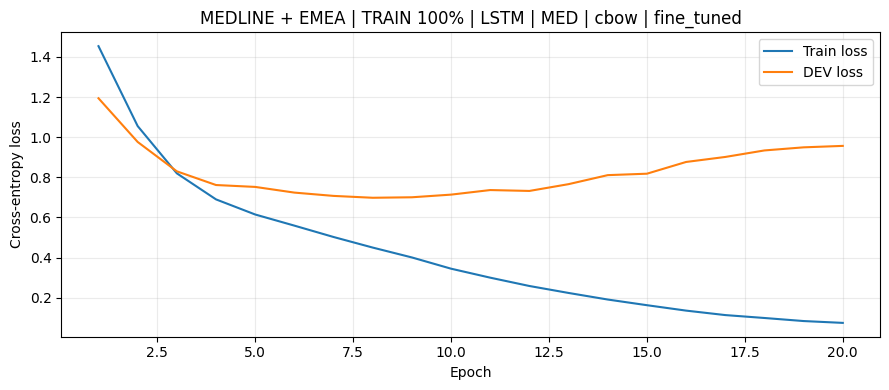

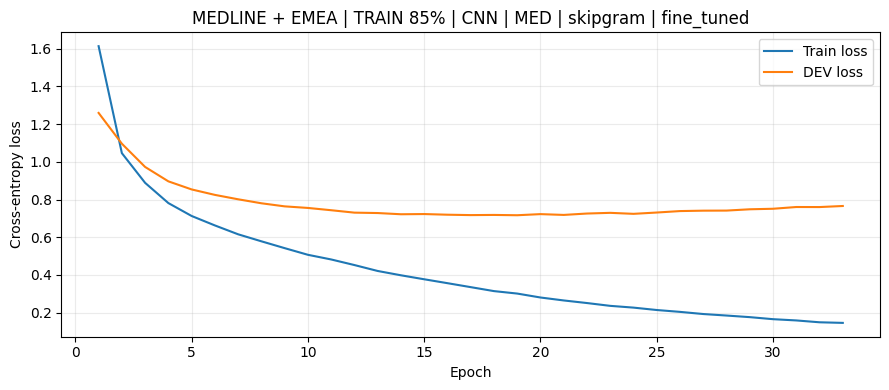

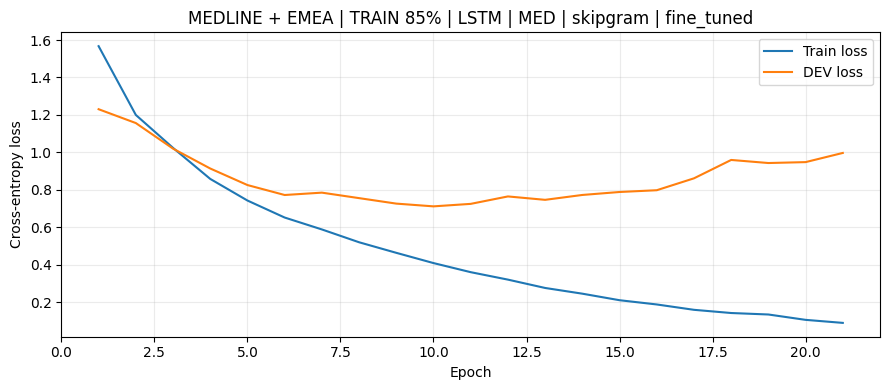

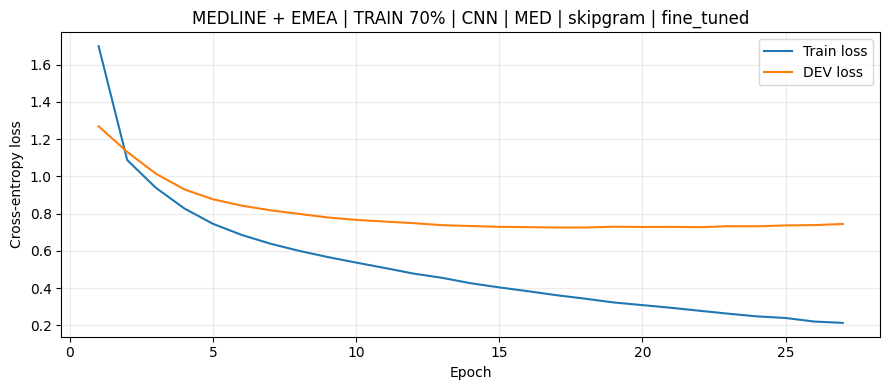

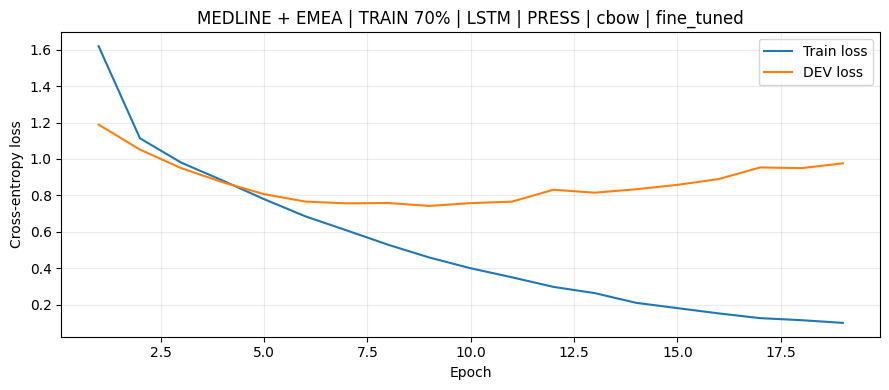

In [30]:
best_dev_indices = dev_results.groupby(
    ["dataset", "train_fraction", "architecture"]
)["entity_f1"].idxmax()

best_dev_models = (
    dev_results.loc[best_dev_indices]
    .sort_values(
        ["dataset", "train_fraction", "architecture"],
        ascending=[True, False, True],
    )
    .reset_index(drop=True)
)

display(best_dev_models.round(4))

for row in best_dev_models.itertuples(index=False):
    plot_run_loss(
        dataset=row.dataset,
        train_fraction=row.train_fraction,
        architecture=row.architecture,
        corpus=row.corpus,
        embedding=row.embedding,
        mode=row.mode,
    )


## 12. Final TEST results

TEST is always evaluated at **100%**, after DEV checkpoint selection.

The table contains all dataset, architecture, embedding-condition and TRAIN-fraction combinations.


In [31]:
display(
    test_results.sort_values(
        ["dataset", "train_fraction", "architecture", "entity_f1"],
        ascending=[True, False, True, False],
    )
    .reset_index(drop=True)
    .round(4)
)


,dataset,train_fraction,train_reduction,dev_fraction,train_sentences,dev_sentences,architecture,corpus,embedding,mode,best_epoch,entity_f1,sentence_exact_match
0,EMEA,1.0,0.0,1.0,636,550,CNN,PRESS,cbow,fine_tuned,18,0.3971,0.0680
1,EMEA,1.0,0.0,1.0,636,550,CNN,MED,cbow,fine_tuned,46,0.3854,0.0699
2,EMEA,1.0,0.0,1.0,636,550,CNN,RANDOM,random,random,24,0.3822,0.0699
3,EMEA,1.0,0.0,1.0,636,550,CNN,MED,skipgram,fine_tuned,34,0.3789,0.0563
4,EMEA,1.0,0.0,1.0,636,550,CNN,PRESS,cbow,frozen,20,0.3777,0.0563
...,...,...,...,...,...,...,...,...,...,...,...,...,...
229,MEDLINE + EMEA,0.7,0.3,0.7,999,939,LSTM,PRESS,skipgram,fine_tuned,14,0.2998,0.0508
230,MEDLINE + EMEA,0.7,0.3,0.7,999,939,LSTM,PRESS,skipgram,frozen,14,0.2989,0.0485
231,MEDLINE + EMEA,0.7,0.3,0.7,999,939,LSTM,MED,skipgram,frozen,14,0.2876,0.0508
232,MEDLINE + EMEA,0.7,0.3,0.7,999,939,LSTM,PRESS,fasttext,frozen,15,0.2685,0.0417
